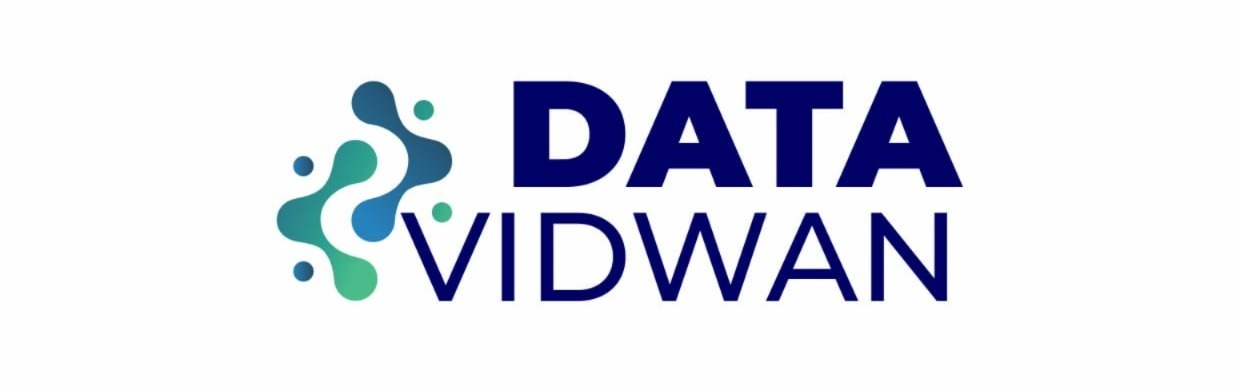

# **What is XGBoost?**

XGBoost stands for Extreme Gradient Boosting. It is one of the most powerful and popular machine-learning algorithms used today. XGBoost is based on the concept of boosting, where multiple weak models (usually decision trees) are combined to create one strong model.

**Why XGBoost is Powerful ?**

- It handles large datasets efficiently.
- It can learn complex patterns better than simple models.
- It has built-in methods to reduce overfitting.
- It works well for both regression and classification tasks.
- It uses parallel processing, making it faster than traditional boosting algorithms.

**How Boosting Works**

Boosting builds models in sequence, The idea is:
- Train the first decision tree.
- Check its errors.
- Build the next tree that focuses on fixing the previous tree’s errors.
- Continue adding trees, each improving the performance.

Each new tree tries to reduce the errors made by previous trees. At the end, all trees are combined to give the final prediction.

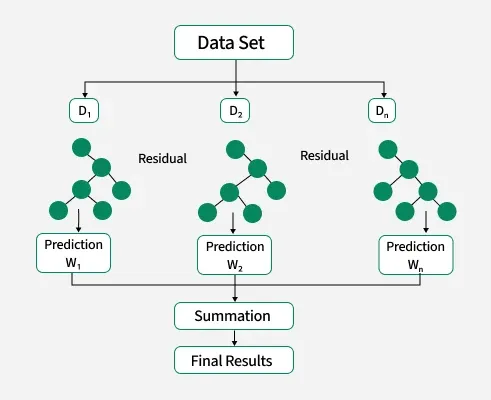

**How XGBoost Improves Boosting**

XGboost adds several enhancements:

**1. Gradient Boosting Optimization**
- Instead of simply correcting errors, XGBoost uses gradients (from calculus) to better understand how to improve the model with each new tree.

**2. Regularization**
- XGBoost includes L1 and L2 regularization to prevent overfitting.
- This means it controls tree complexity and keeps the model general.

**3. Handling Missing Values**

- XGBoost automatically learns the best direction to take when data is missing.

**4. Tree Pruning**

- XGBoost grows trees depth-wise and then prunes unnecessary branches, making the model faster and more accurate.

**5. Parallel Processing**

- Unlike classic boosting, XGBoost can build trees using multiple CPU cores, making training much faster.

- XGBoost is a highly optimized version of gradient boosting.
- It builds many small decision trees in sequence, each correcting the mistakes of the previous one.
- Because of its speed, accuracy, regularization, and ability to handle complex data, it is one of the top choices for solving practical machine-learning problems.

**XGBoost Works for Both Regression and Classification**

XGBoost is a flexible algorithm that can be applied to two major types of machine-learning problems:

- Regression
- Classification

# **1. XGBoost Regression**

XGBoost Regression predicts continuous numerical values.

**How it works**

- It starts with a simple prediction (like the average of all y-values).
- Then it builds small decision trees to reduce the errors step by step.
- Each new tree focuses on where the previous trees performed poorly.
- Gradients are used to decide how to correct the errors.
- All the trees are combined to create the final prediction.


**Why XGboost Regression Performs So Well ?**

- Learns from mistakes gradually
- Reduces errors using gradient information
- Controls tree complexity
- Uses shrinkage/learning rate for stability
- Combines many small trees instead of one large overfitted tree

This leads to:
- Higher accuracy
- Lower error
- More stable predictions

**Problem Statement**

The goal of this project is to predict the total number of bike rentals in a given hour using various environmental and situational features from the dataset.

We will use XGBoost Regression to learn the relationship between input features (such as temperature, season, humidity, weather conditions, and windspeed) and the final target value count, which represents the total number of bikes rented (casual + registered users).

This model will help us understand how different factors influence bike rental demand and allow us to predict future rental counts with high accuracy.

**Libraries**

In [2]:
# Install XGBoost (if not installed)
!pip install xgboost

In [3]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train-test split & metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# XGBoost Regressor
from xgboost import XGBRegressor

**Load Dataset**

In [4]:
from google.colab import files
uploaded = files.upload()

Saving bike_rentals.csv to bike_rentals.csv


In [5]:
df = pd.read_csv("bike_rentals.csv")
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [7]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [15]:
df = pd.read_csv("bike_rentals.csv") # Re-load the DataFrame to ensure 'datetime' column is present
df['datetime'] = pd.to_datetime(df['datetime'])

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['weekday'] = df['datetime'].dt.weekday

**Why We Extracted Datetime Features**

Originally, datetime was just a text column like:
- 2011-01-01 00:00:00
- 2011-01-01 01:00:00

The model cannot learn anything from a string.

So we converted it into meaningful numeric features:
  - df['hour']      0–23
  - df['day']       1–31
  - df['month']     1–12
  - df['year']      2011 / 2012
  - df['weekday']   0–6 (Mon–Sun)

These features are extremely important because bike rental demand follows time patterns.


**Why Each Feature Helps the Model**

**1. hour**

Bike rentals change heavily by hour:

- Morning rush (7–9 AM)
- Evening rush (5–7 PM)
- Late night = almost zero rentals

This feature alone boosts accuracy massively.

**2. day**

Some days have higher rentals due to:

- Events
- Weekends
- Beginning/end of month

**3. month**

Weather changes by month:

- Summer → more rentals
- Winter → fewer rentals

**4. year**

Demand usually increases every year due to:

- More users
- More bikes added

**5. weekday**

Weekdays vs weekends have completely different rental behavior.

**Columns to Remove**

**1. datetime**

- It is a string column and cannot be used directly by XGBoost.
- We are not extracting hour/day/month features in this workflow.
So we drop it.

**2. casual & registered**

- These two columns directly add up to the target column:
  - count = casual + registered
- If we keep them, the model will cheat and get unrealistically high accuracy.
So both must be removed.

In [16]:
df = df.drop(columns=['datetime', 'casual', 'registered'])
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,day,month,year,weekday
0,1,0,0,1,9.84,14.395,81,0.0,16,0,1,1,2011,5
1,1,0,0,1,9.02,13.635,80,0.0,40,1,1,1,2011,5
2,1,0,0,1,9.02,13.635,80,0.0,32,2,1,1,2011,5
3,1,0,0,1,9.84,14.395,75,0.0,13,3,1,1,2011,5
4,1,0,0,1,9.84,14.395,75,0.0,1,4,1,1,2011,5


**Train-Test Split**

In [17]:
X = df.drop('count', axis=1)
y = df['count']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((8708, 13), (2178, 13))

**Why Did We Use count as the Target?**

- Your goal in this project is to predict how many bikes will be rented in a given hour.
- The dataset has these 3 related columns:
  - casual → number of casual users
  - registered → number of registered users
  - count → total bikes rented

count = casual + registered


**Why NOT use casual or registered as target?**

Because:

- If you predict only casual, you miss registered users.
- If you predict only registered, you miss casual users.
- If you try to predict both separately, complexity becomes unnecessary.

In [18]:
# Create the model
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

**1. n_estimators=200**

- This means the model will build 200 small decision trees.
- More trees usually improve accuracy.

**2. learning_rate=0.1**

- Controls how fast the model learns.
- A smaller value means slow but stable learning.
- 0.1 is a good balanced value.

**3. max_depth=6**

- Each tree can go up to depth 6.
- Higher depth = more complex tree.
- Depth 6 works well for medium-size datasets.

**4. subsample=0.8**

- Uses only 80% of the data for each tree.
- This reduces overfitting and increases   generalization.

**5. colsample_bytree=0.8**

- Uses 80% of the features for each tree.
- Also helps in reducing overfitting.

**6. random_state=42**

- Keeps the results the same every time you run the code.

In [19]:
 # Make predictions
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE : 1361.638671875
RMSE: 36.900388505746115
R² Score: 0.9587469100952148


**Actual vs Predicted graph**

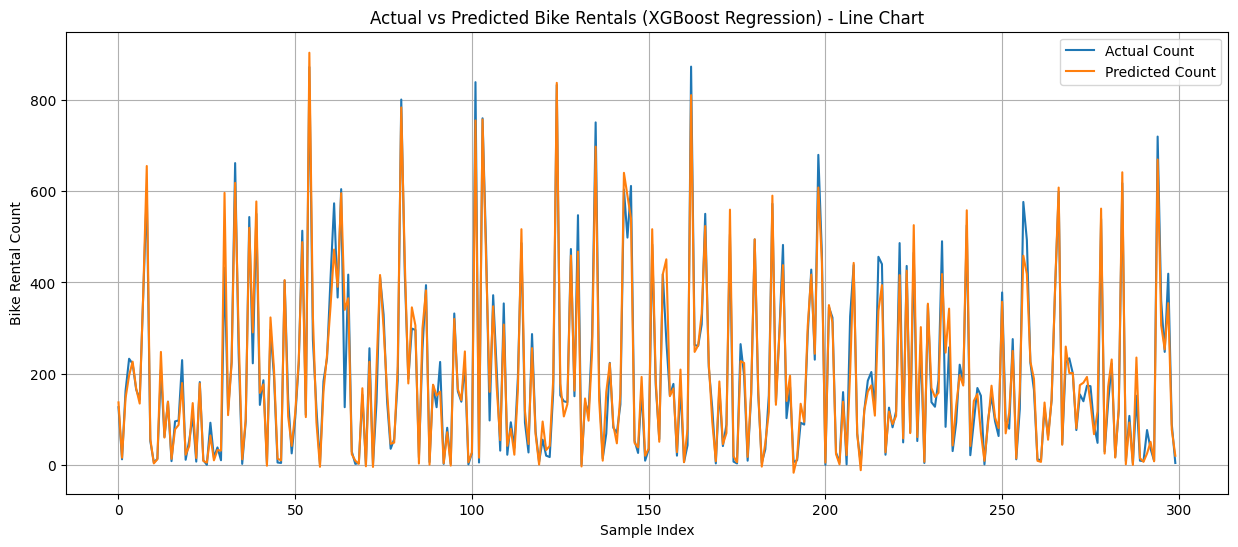

In [21]:
plt.figure(figsize=(15, 6))

# Plot actual values as a line
plt.plot(y_test.values[:300], label='Actual Count')

# Plot predicted values as a line
plt.plot(y_pred[:300], label='Predicted Count')

plt.xlabel('Sample Index')
plt.ylabel('Bike Rental Count')
plt.title('Actual vs Predicted Bike Rentals (XGBoost Regression) - Line Chart')
plt.legend()
plt.grid(True)
plt.show()


**Feature Importance Plot**

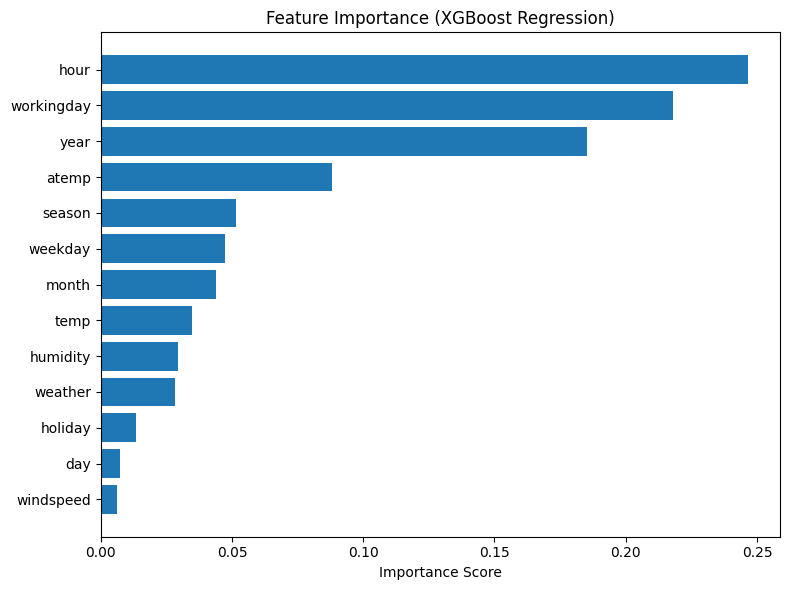

In [22]:
# Get feature names (columns used in X)
feature_names = X.columns

# Get importance values from model
importances = model.feature_importances_

# Sort features from least to most important
indices = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(range(len(importances)), importances[indices])
plt.yticks(range(len(importances)), feature_names[indices])

plt.xlabel('Importance Score')
plt.title('Feature Importance (XGBoost Regression)')
plt.tight_layout()
plt.show()

- Each bar represents how important a feature is for prediction.
- Longer bar = more influence on the model.
- Usually hour, temp, humidity become the top features for bike rentals.
- Helps students understand which factors affect rental demand the most.

In [23]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,day,month,year,weekday
0,1,0,0,1,9.84,14.395,81,0.0,16,0,1,1,2011,5
1,1,0,0,1,9.02,13.635,80,0.0,40,1,1,1,2011,5
2,1,0,0,1,9.02,13.635,80,0.0,32,2,1,1,2011,5
3,1,0,0,1,9.84,14.395,75,0.0,13,3,1,1,2011,5
4,1,0,0,1,9.84,14.395,75,0.0,1,4,1,1,2011,5


**Inference**

In [24]:
# Example input values (you can change these)
input_data = {
    'season': [1],        # season encoded as per dataset
    'holiday': [0],       # 0 = no, 1 = yes
    'workingday': [0],    # 1 = working day
    'weather': [1],       # 1 = clear weather
    'temp': [9.84],       # temperature in Celsius
    'atemp': [14.395],      # feels-like temperature
    'humidity': [81],     # humidity %
    'windspeed': [0.0],  # wind speed
    'hour': [0],          # 9 AM
    'day': [1],          # day of the month
    'month': [1],         # June
    'year': [2011],       # year value used in dataset
    'weekday': [5]        # weekday number (0 = Mon)
}

# Convert to DataFrame
input_df = pd.DataFrame(input_data)

# Make prediction
prediction = model.predict(input_df)[0]

# Print output cleanly
print(f"Predicted Bike Rentals: {prediction:.2f}")

Predicted Bike Rentals: 35.51


In [25]:
import joblib
joblib.dump(model, "xgboost_bike_model.pkl")

['xgboost_bike_model.pkl']